# QEC Plot Notebook

This notebook is used to generate the main tables and figures for the paper from the simulation logs.

The four main experiment groups are:

1. Gate-fidelity sweep
   This compares `none`, `cec`, and `qec` while sweeping two-qubit gate fidelity, with one-qubit and measurement fidelity scaled accordingly. The goal is to identify the practical gate-fidelity threshold for each correction method.

2. Coherence-time sweep
   This compares `none`, `cec`, and `qec` while sweeping memory coherence time. The goal is to see how strongly each method depends on memory quality and where each approach begins to fail.

3. End-to-end distance sweep
   This keeps the elementary-link distance fixed at `10 km` and increases the total communication distance. The goal is to measure both latency and end-to-end fidelity as distance grows.

4. Link-count sweep
   This varies the number of links in the chain while keeping the elementary-link distance fixed at `10 km`. The goal is to study how end-to-end fidelity changes as the number of hops increases.


In [360]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


## Parse Logs

These regex patterns parse the log filenames and result lines.


In [361]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), "
    r"(?:fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+), fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+), )?"
    r"fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"(?:meas=(?P<meas>[0-9.]+|cfg),)?"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"(?:physbell=(?P<physbell>[0-9.]+|cfg),)?"
    r"ts=(?P<ts>\d{8}_\d{4})"
)

## Load Data

This function loads one log directory into a pandas dataframe.


In [362]:
def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue
        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue
                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "measurement_fidelity": None if meta.get("meas") in (None, "cfg") else float(meta["meas"]),
                    "initialization_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": None if meta.get("physbell") in (None, "cfg") else float(meta["physbell"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                    "fidelity_raw": float(line_match["fidelity_raw"]) if line_match["fidelity_raw"] is not None else float(line_match["fidelity"]),
                    "fidelity_corrected": float(line_match["fidelity_corrected"]) if line_match["fidelity_corrected"] is not None else float(line_match["fidelity"]),
                })
    return pd.DataFrame(rows)


# Experiments


In [363]:
run_after = None


In [364]:
output_dir = Path("/Users/patange/Documents/Argonne/QEC/plot_pngs")
output_dir.mkdir(parents=True, exist_ok=True)


## Qubit Overhead Table

Show total qubit overhead as a function of correction mode, FT preparation mode, and the number of nodes `n`.


In [365]:
n = 11  # Number of nodes in the linear chain.

qec_ancillas_by_mode = {"none": 0, "cec": 0, "qec": 3}
ft_ancillas_by_mode = {"none": 0, "minimal": 1, "standard": 4}

rows = []
for correction_mode, qec_ancillas in qec_ancillas_by_mode.items():
    for ft_prep_mode, ft_ancillas in ft_ancillas_by_mode.items():
        ancillas_per_end = max(qec_ancillas, ft_ancillas)
        comm_qubits_per_end = 7
        data_qubits_per_end = 7
        qubits_per_end = comm_qubits_per_end + data_qubits_per_end + ancillas_per_end
        total_qubits = 2 * (n - 1) * qubits_per_end
        rows.append({
            "n": n,
            "correction_mode": correction_mode,
            "ft_prep_mode": ft_prep_mode,
            "comm_qubits_per_end": comm_qubits_per_end,
            "data_qubits_per_end": data_qubits_per_end,
            "reserved_ancillas_per_end": ancillas_per_end,
            "qubits_per_end": qubits_per_end,
            "total_qubits": total_qubits,
        })

pd.DataFrame(rows).sort_values(["correction_mode", "ft_prep_mode"]).reset_index(drop=True)


,n,correction_mode,ft_prep_mode,comm_qubits_per_end,data_qubits_per_end,reserved_ancillas_per_end,qubits_per_end,total_qubits
0,11,cec,minimal,7,7,1,15,300
1,11,cec,none,7,7,0,14,280
2,11,cec,standard,7,7,4,18,360
3,11,none,minimal,7,7,1,15,300
4,11,none,none,7,7,0,14,280
5,11,none,standard,7,7,4,18,360
6,11,qec,minimal,7,7,3,17,340
7,11,qec,none,7,7,3,17,340
8,11,qec,standard,7,7,4,18,360


## Graph 1: Gate-Fidelity Sweep

Plot end-to-end fidelity versus two-qubit gate fidelity for `none`, `cec`, and `qec`.


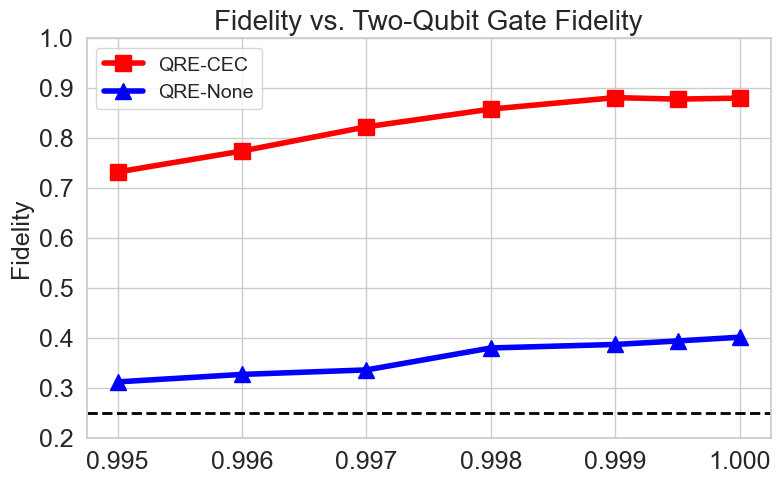

In [386]:
graph1_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph1_twoqubit_gate_sweep")
graph1_df = load_runner_logs(graph1_log_dir)

if graph1_df.empty:
    print("No Graph 1 data found.")
else:
    graph1_summary = (
        graph1_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_raw=("fidelity_raw", "mean"),
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
        )
        .sort_values(["two_qubit_gate_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for protocol in ["cec", "none"]:
        data = graph1_summary[graph1_summary["correction_mode"] == protocol]
        ax.plot(data["two_qubit_gate_fidelity"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=20)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=14, loc="upper left")
    plt.tight_layout()
    plt.savefig(output_dir / "fidelity_vs_two_qubit_gate_fidelity.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph1_summary



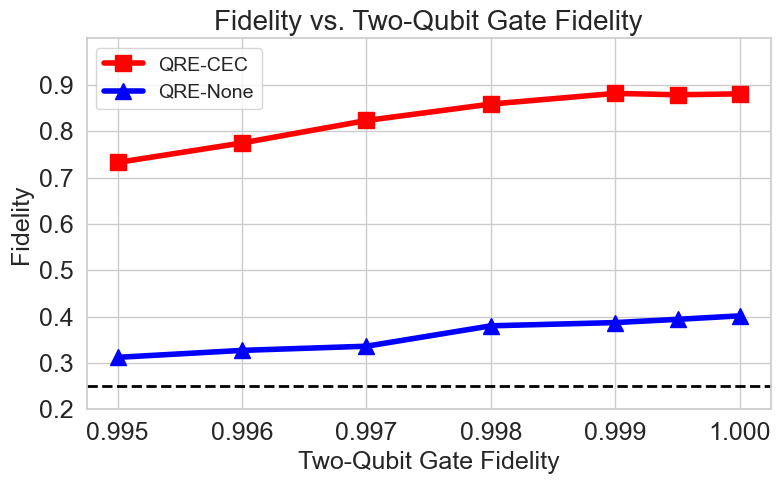

,two_qubit_gate_fidelity,correction_mode,mean_fidelity_raw,mean_fidelity_corrected
0,0.9950,cec,0.5455,0.7325
1,0.9950,none,0.3020,0.3120
2,0.9950,qec,0.2980,0.3380
3,0.9960,cec,0.5710,0.7745
4,0.9960,none,0.3075,0.3270
5,0.9960,qec,0.3270,0.3805
6,0.9970,cec,0.6535,0.8230
7,0.9970,none,0.3260,0.3360
8,0.9970,qec,0.3825,0.4225
9,0.9980,cec,0.6580,0.8585


In [387]:
graph1_runner2_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph1_twoqubit_gate_sweep")
graph1_runner2_df = load_runner_logs(graph1_runner2_log_dir)

# Average all completed runs at each two-qubit fidelity and protocol setting.
graph1_runner2_summary = graph1_runner2_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean")).sort_values(["two_qubit_gate_fidelity", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue"}
names = {"cec": "QRE-CEC", "none": "QRE-None"}
markers = {"cec": "s", "none": "^"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

for protocol in ["cec", "none"]:
    data = graph1_runner2_summary[graph1_runner2_summary["correction_mode"] == protocol]

    ax.plot(data["two_qubit_gate_fidelity"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
ax.set_ylabel("Fidelity", fontsize=18)
ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=20)
ax.set_ylim(0.2, 1.0)
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=14, loc="upper left")

plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_two_qubit_gate_fidelity_runner2.png", dpi=300, bbox_inches="tight")
plt.show()

graph1_runner2_summary



## Graph 2: Coherence-Time Sweep

Plot end-to-end fidelity versus coherence time for `none`, `cec`, and `qec`.


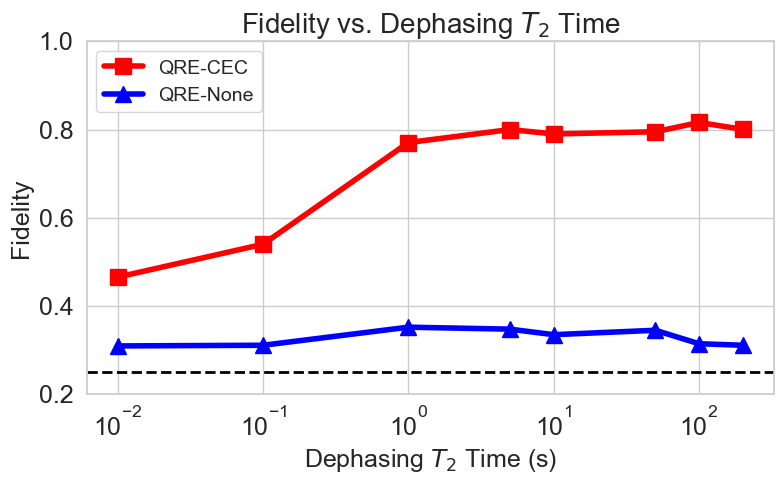

In [388]:
graph2_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph2_t2_sweep")
graph2_df = load_runner_logs(graph2_log_dir)

if graph2_df.empty:
    print("No Graph 2 data found.")
else:
    graph2_summary = (
        graph2_df.groupby(["data_t2", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_raw=("fidelity_raw", "mean"),
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
        )
        .sort_values(["data_t2", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for protocol in ["cec", "none"]:
        data = graph2_summary[graph2_summary["correction_mode"] == protocol]
        ax.plot(data["data_t2"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
    ax.set_xlabel("Dephasing $T_2$ Time (s)", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Dephasing $T_2$ Time", fontsize=20)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.set_xscale("log")
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=14, loc="upper left")
    plt.tight_layout()
    plt.savefig(output_dir / "fidelity_vs_coherence_time.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph2_summary



## Graph 3: End-to-End Distance Sweep

Plot both latency and end-to-end fidelity versus total distance, with `10 km` elementary links.


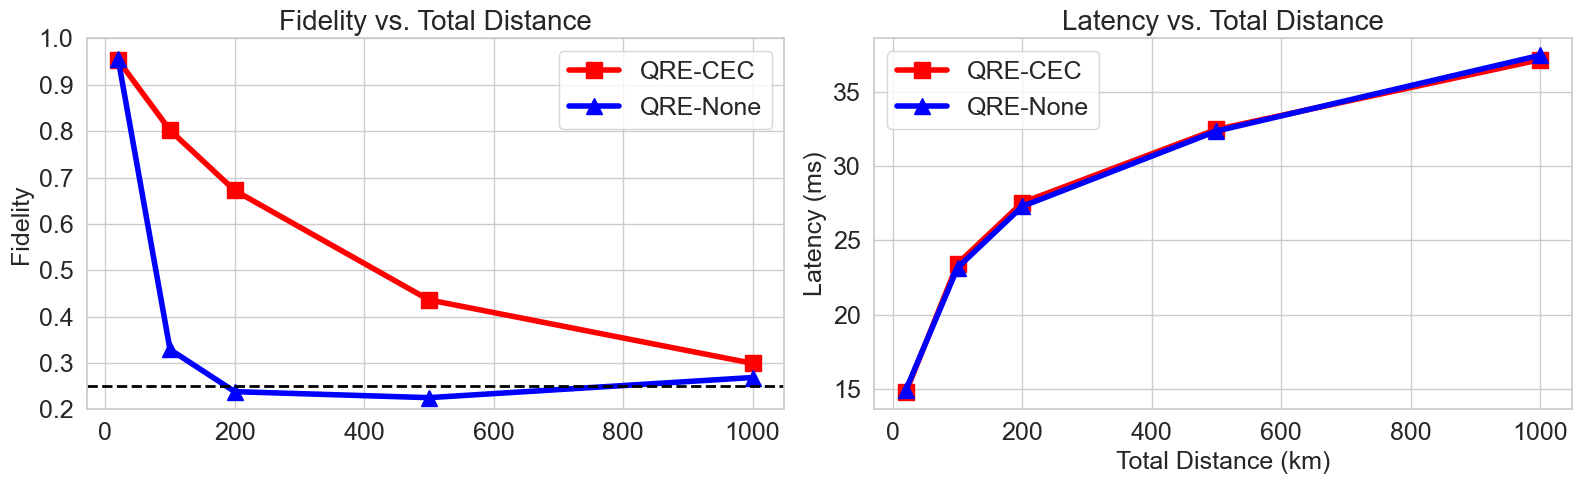

In [389]:
graph3_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph3_distance_sweep")
graph3_df = load_runner_logs(graph3_log_dir)


# Build one table with the mean latency and fidelity at each distance and protocol.
graph3_summary = graph3_df.groupby(["total_distance_km", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["total_distance_km", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue"}
names = {"cec": "QRE-CEC", "none": "QRE-None"}
markers = {"cec": "s", "none": "^"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Left panel: latency.
ax0 = axes[1]
# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "none"]:
    data = graph3_summary[(graph3_summary["correction_mode"] == protocol) & (graph3_summary["total_distance_km"] != 2000)]
    ax0.plot(data["total_distance_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
ax0.set_xlabel("Total Distance (km)", fontsize=18)
ax0.set_ylabel("Latency (ms)", fontsize=18)
ax0.set_title("Latency vs. Total Distance", fontsize=20)
ax0.tick_params(axis="both", labelsize=18)

# Right panel: fidelity.
ax1 = axes[0]
for protocol in ["cec", "none"]:
    data = graph3_summary[(graph3_summary["correction_mode"] == protocol) & (graph3_summary["total_distance_km"] != 2000)]
    ax1.plot(data["total_distance_km"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
ax1.set_ylabel("Fidelity", fontsize=18)
ax1.set_title("Fidelity vs. Total Distance", fontsize=20)
ax1.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax1.set_ylim(0.2, 1.0)
ax1.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax1.tick_params(axis="both", labelsize=18)

ax0.legend(fontsize=18)
ax1.legend(fontsize=18)

plt.tight_layout()
plt.savefig(output_dir / "distance_sweep_varryingNodes.png", dpi=300, bbox_inches="tight")
plt.show()



## Graph 4: Link-Count Sweep

Plot end-to-end fidelity versus number of links, with `10 km` elementary links.


/var/folders/pz/qmtxblt536z17q2qg96mb3740000gn/T/ipykernel_60688/1362386808.py:39: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=0, top=5000)  # Set a minimum y-value to avoid issues with log scale.


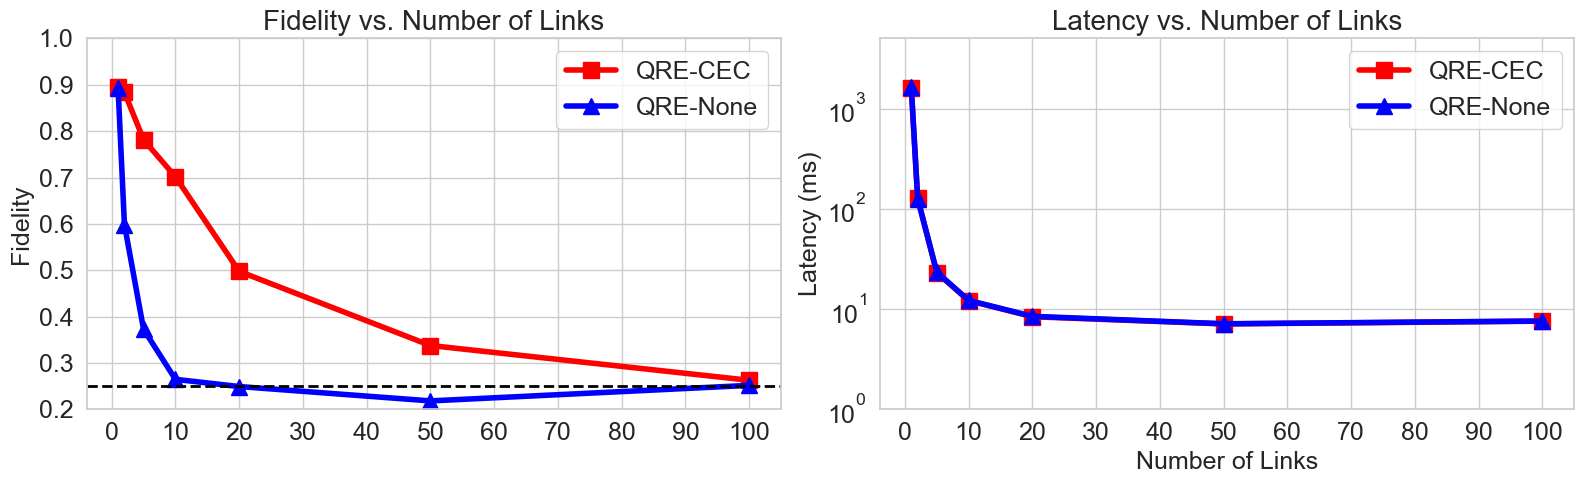

In [390]:
graph4_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph4_link_count_sweep")
graph4_df = load_runner_logs(graph4_log_dir)

if graph4_df.empty:
    print("No Graph 4 data found.")
else:
    # Average all completed runs at each link count and protocol setting.
    graph4_summary = graph4_df.groupby(["num_links", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["num_links", "correction_mode"]).reset_index(drop=True)
    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    # Left panel: fidelity.
    ax0 = axes[0]
    # Draw each protocol separately so the marker shapes stay fixed.
    for protocol in ["cec", "none"]:
        data = graph4_summary[graph4_summary["correction_mode"] == protocol]
        ax0.plot(data["num_links"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
    ax0.set_ylabel("Fidelity", fontsize=18)
    ax0.set_title("Fidelity vs. Number of Links", fontsize=20)
    ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax0.set_ylim(0.2, 1.0)
    ax0.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax0.set_xticks([0,10,20,30,40,50,60,70,80,90,100])

    ax0.tick_params(axis="both", labelsize=18)

    # Right panel: latency.
    ax1 = axes[1]
    for protocol in ["cec", "none"]:
        data = graph4_summary[graph4_summary["correction_mode"] == protocol]
        ax1.plot(data["num_links"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
    ax1.set_xlabel("Number of Links", fontsize=18)
    ax1.set_ylabel("Latency (ms)", fontsize=18)
    ax1.set_title("Latency vs. Number of Links", fontsize=20)
    ax1.set_yscale("log")
    # ax1.set_xscale("log")
    ax1.set_ylim(bottom=0, top=5000)  # Set a minimum y-value to avoid issues with log scale.
    ax1.tick_params(axis="both", labelsize=18)
    ax1.set_yticks([1,10, 100, 1000,])
    ax1.set_xticks([0,10,20,30,40,50,60,70,80,90,100])

    ax0.legend(fontsize=18)
    ax1.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(output_dir / "number_of_links_sweep_E2E100km.png", dpi=300, bbox_inches="tight")
    plt.show()



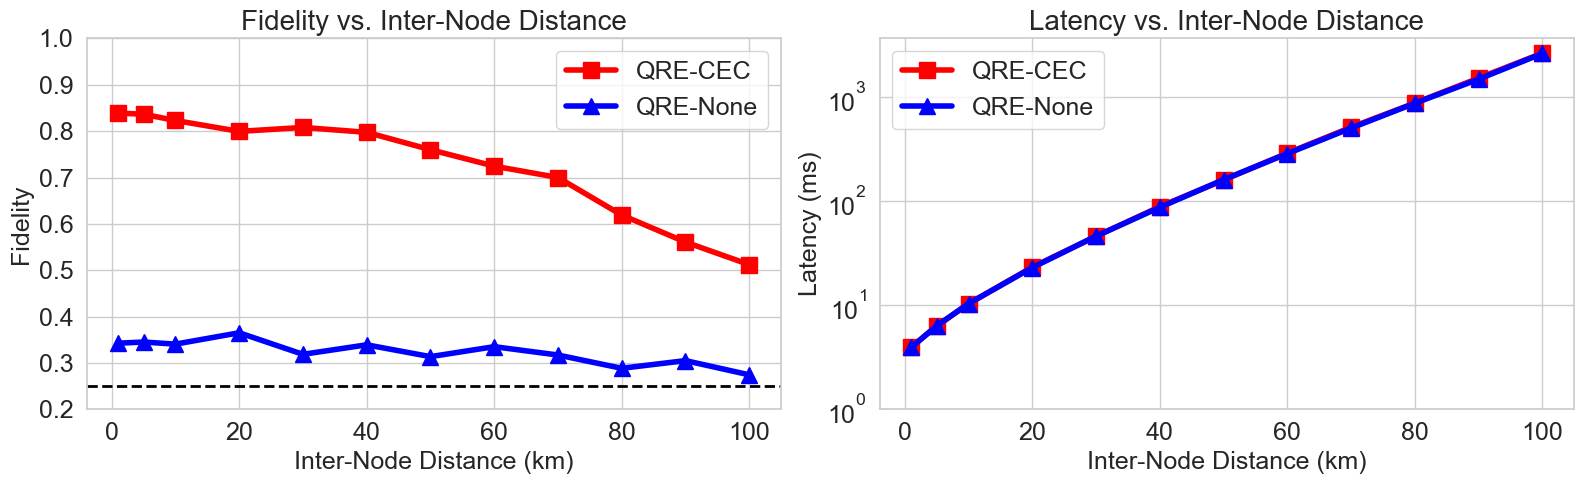

,elementary_link_km,correction_mode,mean_fidelity_raw,mean_fidelity_corrected,mean_latency_ms
0,1.0,cec,0.634000,0.839000,3.960453
1,1.0,none,0.318000,0.342500,3.933126
2,1.0,qec,0.354500,0.411000,3.968007
3,5.0,cec,0.617000,0.836500,6.301286
4,5.0,none,0.343500,0.345000,6.357791
5,5.0,qec,0.387000,0.430500,6.361286
6,10.0,cec,0.642000,0.823000,10.344757
7,10.0,none,0.340000,0.340500,10.382584
8,10.0,qec,0.347500,0.384000,10.241328
9,20.0,cec,0.600500,0.799500,23.266423


In [396]:
graph5_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph5_inter_node_distance_sweep")
graph5_df = load_runner_logs(graph5_log_dir)

# Average all completed runs at each inter-node distance and protocol setting.
graph5_summary = graph5_df.groupby(["elementary_link_km", "correction_mode"], as_index=False).agg(mean_fidelity_raw=("fidelity_raw", "mean"), mean_fidelity_corrected=("fidelity_corrected", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["elementary_link_km", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue"}
names = {"cec": "QRE-CEC", "none": "QRE-None"}
markers = {"cec": "s", "none": "^"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

for protocol in ["cec", "none"]:
    data = graph5_summary[(graph5_summary["correction_mode"] == protocol) & (~graph5_summary["elementary_link_km"].isin([2.5, 7.5, 110,120]))]
    axes[0].plot(data["elementary_link_km"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
    axes[1].plot(data["elementary_link_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

axes[0].set_xlabel("Inter-Node Distance (km)", fontsize=18)
axes[0].set_ylabel("Fidelity", fontsize=18)
axes[0].set_title("Fidelity vs. Inter-Node Distance", fontsize=20)
axes[0].axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
axes[0].set_ylim(0.2, 1.0)
axes[0].set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
axes[0].tick_params(axis="both", labelsize=18)
axes[0].legend(fontsize=18)

axes[1].set_xlabel("Inter-Node Distance (km)", fontsize=18)
axes[1].set_ylabel("Latency (ms)", fontsize=18)
axes[1].set_title("Latency vs. Inter-Node Distance", fontsize=20)
axes[1].tick_params(axis="both", labelsize=18)
axes[1].legend(fontsize=18)
axes[1].set_yscale("log")
axes[1].set_yticks([1e0, 1e1, 1e2, 1e3])


plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_inter_node_distance_5linktopology.png", dpi=300, bbox_inches="tight")
plt.show()

graph5_summary




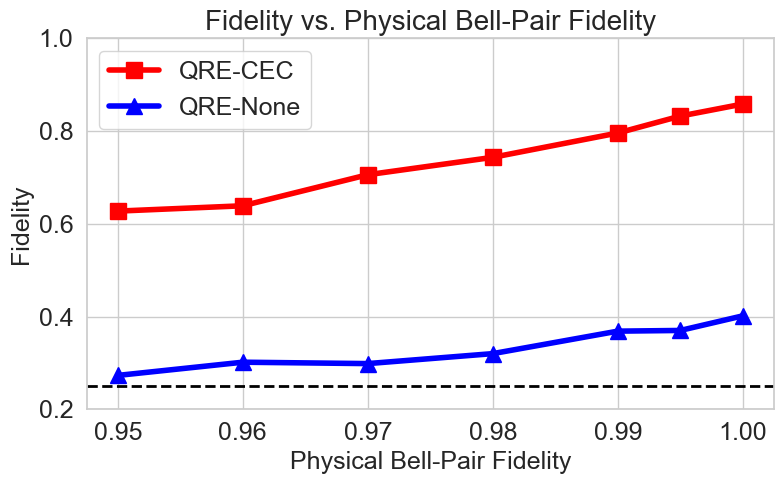

In [395]:
graph6_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph6_physical_bell_pair_fidelity_sweep")
graph6_df = load_runner_logs(graph6_log_dir)

if graph6_df.empty:
    print("No Graph 6 data found.")
else:
    graph6_summary = (
        graph6_df.groupby(["physical_bell_pair_fidelity", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_raw=("fidelity_raw", "mean"),
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
        )
        .sort_values(["physical_bell_pair_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for protocol in ["cec", "none"]:
        data = graph6_summary[graph6_summary["correction_mode"] == protocol]
        ax.plot(data["physical_bell_pair_fidelity"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
    ax.set_xlabel("Physical Bell-Pair Fidelity", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Physical Bell-Pair Fidelity", fontsize=20)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(output_dir / "fidelity_vs_physical_bell_pair_fidelity.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph6_summary



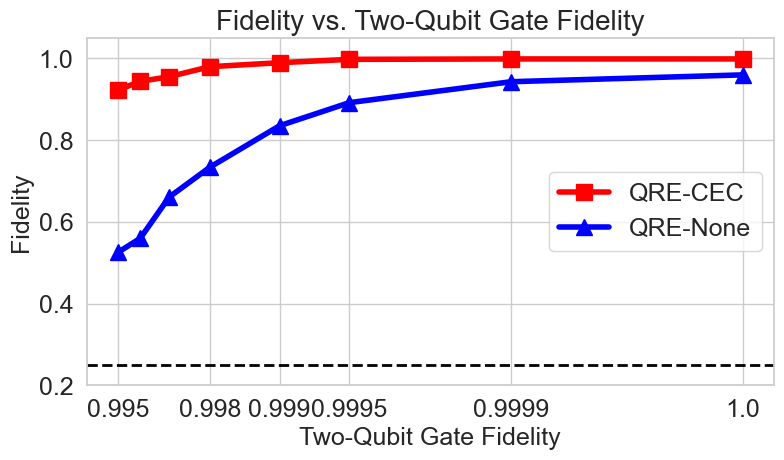

In [394]:
graph7_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph7_twoqubit_gate_fidelity_sweep_nice_params")
graph7_df = load_runner_logs(graph7_log_dir)

if graph7_df.empty:
    print("No Graph 7 data found.")
else:
    graph7_summary = (
        graph7_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_raw=("fidelity_raw", "mean"),
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
        )
        .sort_values(["two_qubit_gate_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )
    graph7_summary["two_qubit_gate_infidelity"] = 1.0 - graph7_summary["two_qubit_gate_fidelity"]
    graph7_summary["two_qubit_gate_infidelity_plot"] = graph7_summary["two_qubit_gate_infidelity"].replace(0.0, 1e-5)

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    for protocol in ["cec", "none"]:
        data = graph7_summary[graph7_summary["correction_mode"] == protocol]
        ax.plot(data["two_qubit_gate_infidelity_plot"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
    ax.set_xscale("log")
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=20)
    ax.set_ylim(0.2, 1.05)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="y", labelsize=18)
    ax.tick_params(axis="x", labelsize=18)
    ax.legend(fontsize=18)

    tick_fidelities = [0.995, 0.998, 0.999, 0.9995, 0.9999, 1.0]
    tick_positions = [1.0 - value if value < 1.0 else 1e-5 for value in tick_fidelities]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(["0.995", "0.998", "0.999", "0.9995", "0.9999", "1.0"])
    ax.invert_xaxis()

    plt.tight_layout()
    plt.subplots_adjust(top=0.86)
    plt.savefig(output_dir / "fidelity_vs_two_qubit_gate_fidelity_nice_params.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph7_summary



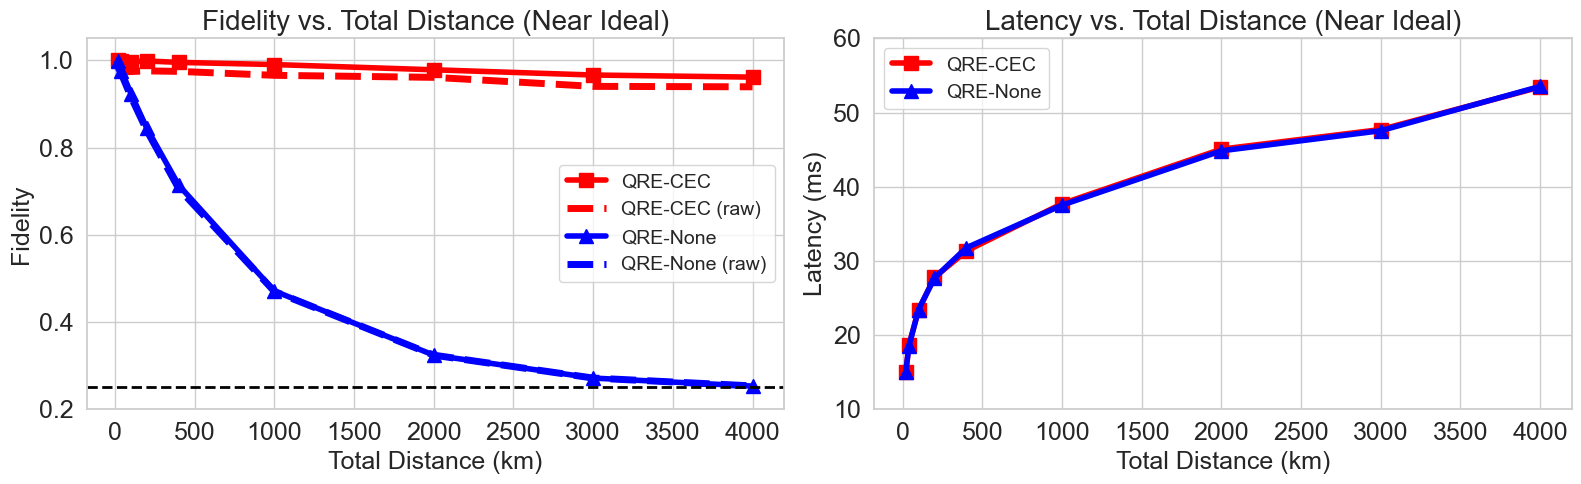

,total_distance_km,correction_mode,mean_fidelity_raw,mean_fidelity_corrected,mean_latency_ms
0,20.0,cec,0.987333,0.999500,15.036897
1,20.0,none,0.982833,0.998833,15.077504
2,20.0,qec,0.983167,0.998833,15.319054
3,40.0,cec,0.973167,0.998500,18.669604
4,40.0,none,0.968667,0.976333,18.524523
5,40.0,qec,0.968000,0.991667,18.576256
6,100.0,cec,0.974167,0.996833,23.378903
7,100.0,none,0.916167,0.923500,23.443548
8,100.0,qec,0.948167,0.968167,23.274514
9,200.0,cec,0.975667,0.998333,27.781928


In [397]:
graph8_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph8_ideal_params_distance_sweep")
graph8_df = load_runner_logs(graph8_log_dir)

graph8_summary = (
    graph8_df.groupby(["total_distance_km", "correction_mode"], as_index=False)
    .agg(
        mean_fidelity_raw=("fidelity_raw", "mean"),
        mean_fidelity_corrected=("fidelity_corrected", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
    )
    .sort_values(["total_distance_km", "correction_mode"])
    .reset_index(drop=True)
)

colors = {"cec": "red", "none": "blue"}
names = {"cec": "QRE-CEC", "none": "QRE-None"}
markers = {"cec": "s", "none": "^"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for protocol in ["cec", "none"]:
    data = graph8_summary[graph8_summary["correction_mode"] == protocol]
    axes[0].plot(
        data["total_distance_km"],
        data["mean_fidelity_corrected"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        linestyle="-",
        label=names[protocol],
    )
    axes[1].plot(
        data["total_distance_km"],
        data["mean_latency_ms"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )

axes[0].set_xlabel("Total Distance (km)", fontsize=18)
axes[0].set_ylabel("Fidelity", fontsize=18)
axes[0].set_title("Fidelity vs. Total Distance (Near Ideal)", fontsize=20)
axes[0].set_ylim(0.2, 1.05)
axes[0].tick_params(axis="both", labelsize=18)
axes[0].legend(fontsize=14)

axes[1].set_xlabel("Total Distance (km)", fontsize=18)
axes[1].set_ylabel("Latency (ms)", fontsize=18)
axes[1].set_title("Latency vs. Total Distance (Near Ideal)", fontsize=20)
axes[1].tick_params(axis="both", labelsize=18)
axes[1].legend(fontsize=14)
axes[1].set_yticks([10,20, 30,40,50,60])

plt.tight_layout()
plt.savefig(output_dir / "distance_sweep_ideal_params_20km.png", dpi=300, bbox_inches="tight")
plt.show()

graph8_summary




In [375]:
import stim

# Create a Tableau simulator
sim = stim.TableauSimulator()

# Prepare |Psi+> = (|00> + |11>) / sqrt(2)
# Start from |00>, apply H to qubit 0, then CNOT(0,1)
sim.h(0)
sim.cnot(0, 1)

# Print the current stabilizer tableau
tableau = sim.current_inverse_tableau()**-1
print("Stabilizer tableau for |Psi+>:")
print(tableau)

Stabilizer tableau for |Psi+>:
+-xz-xz-
| ++ ++
| ZX _Z
| _X XZ


## Runner-Ideal Corrected-Only Plots

These plots use `runner-ideal` logs only and show corrected fidelity only for graphs `1` through `8`.


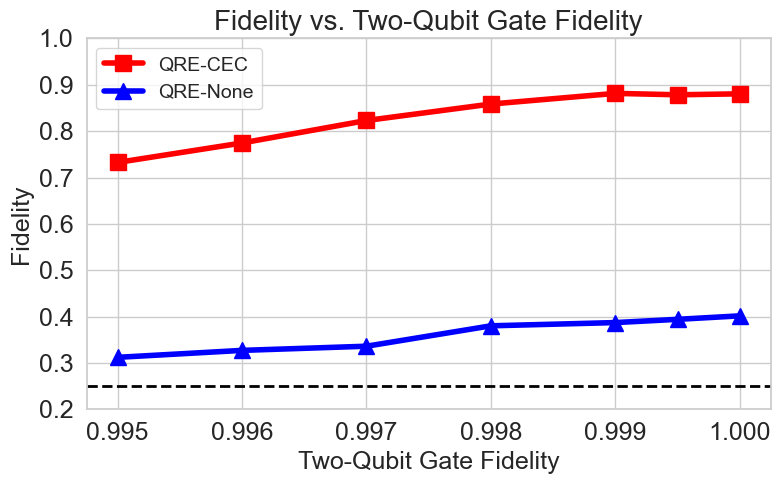

In [376]:
graph1_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph1_twoqubit_gate_sweep")
graph1_corrected_only_df = load_runner_logs(graph1_corrected_only_log_dir)

if graph1_corrected_only_df.empty:
    print("No Graph 1 runner-ideal data found.")
else:
    graph1_corrected_only_summary = (
        graph1_corrected_only_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False)
        .agg(mean_fidelity_corrected=("fidelity_corrected", "mean"))
        .sort_values(["two_qubit_gate_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for protocol in ["cec", "none"]:
        data = graph1_corrected_only_summary[graph1_corrected_only_summary["correction_mode"] == protocol]
        ax.plot(
            data["two_qubit_gate_fidelity"],
            data["mean_fidelity_corrected"],
            color=colors[protocol],
            marker=markers[protocol],
            linewidth=4,
            markersize=12,
            linestyle="-",
            label=names[protocol],
        )

    ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=20)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=14, loc="upper left")
    plt.tight_layout()
    plt.savefig(output_dir / "corrected_fidelity_vs_two_qubit_gate_fidelity_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph1_corrected_only_summary


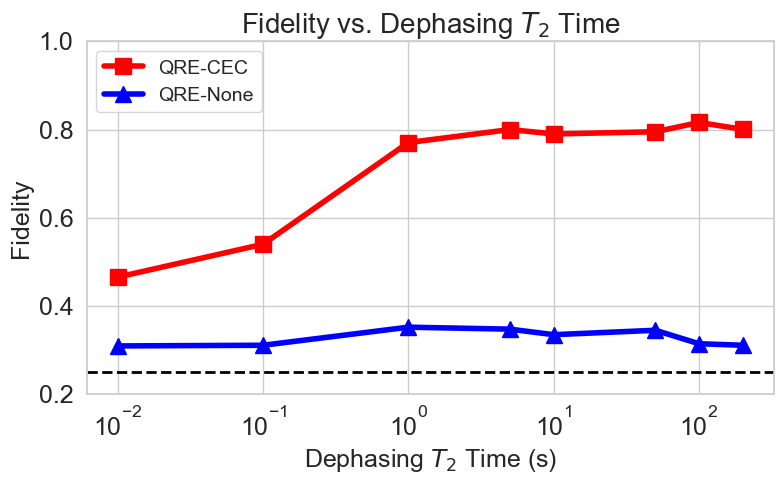

In [377]:
graph2_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph2_t2_sweep")
graph2_corrected_only_df = load_runner_logs(graph2_corrected_only_log_dir)

if graph2_corrected_only_df.empty:
    print("No Graph 2 runner-ideal data found.")
else:
    graph2_corrected_only_summary = (
        graph2_corrected_only_df.groupby(["data_t2", "correction_mode"], as_index=False)
        .agg(mean_fidelity_corrected=("fidelity_corrected", "mean"))
        .sort_values(["data_t2", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for protocol in ["cec", "none"]:
        data = graph2_corrected_only_summary[graph2_corrected_only_summary["correction_mode"] == protocol]
        ax.plot(
            data["data_t2"],
            data["mean_fidelity_corrected"],
            color=colors[protocol],
            marker=markers[protocol],
            linewidth=4,
            markersize=12,
            linestyle="-",
            label=names[protocol],
        )

    ax.set_xscale("log")
    ax.set_xlabel("Dephasing $T_2$ Time (s)", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Dephasing $T_2$ Time", fontsize=20)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=14, loc="upper left")
    plt.tight_layout()
    plt.savefig(output_dir / "corrected_fidelity_vs_coherence_time_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph2_corrected_only_summary


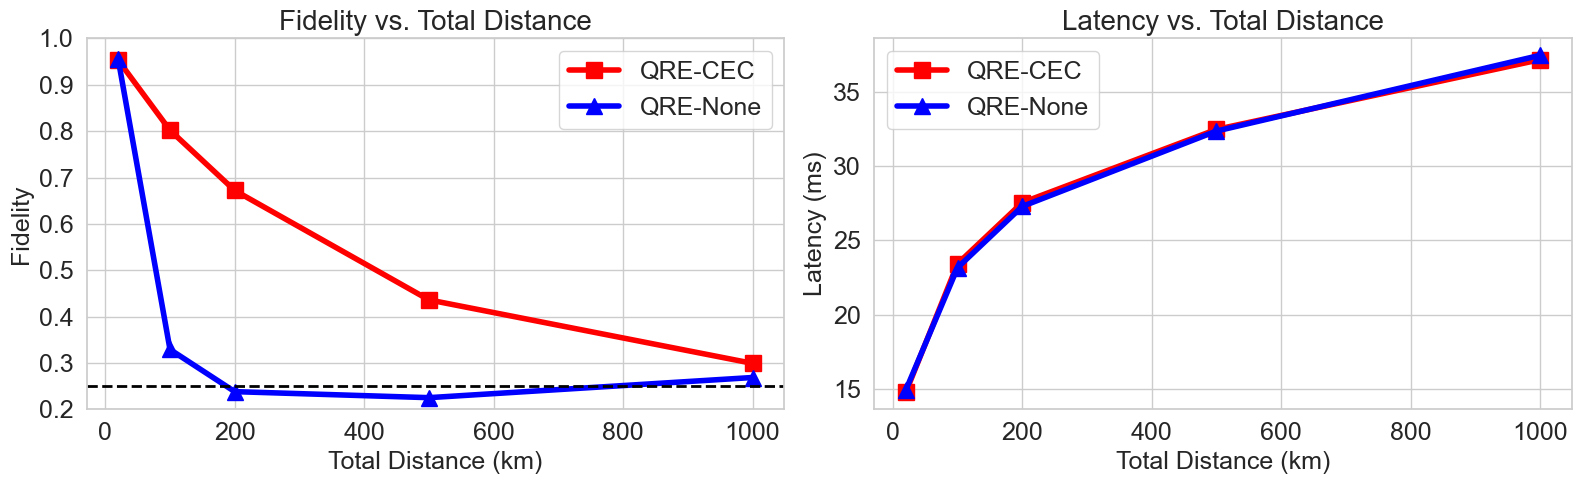

In [378]:
graph3_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph3_distance_sweep")
graph3_corrected_only_df = load_runner_logs(graph3_corrected_only_log_dir)

if graph3_corrected_only_df.empty:
    print("No Graph 3 runner-ideal data found.")
else:
    graph3_corrected_only_summary = (
        graph3_corrected_only_df.groupby(["total_distance_km", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
            mean_latency_ms=("latency_ms", "mean"),
        )
        .sort_values(["total_distance_km", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax0 = axes[0]
    ax1 = axes[1]

    for protocol in ["cec", "none"]:
        data = graph3_corrected_only_summary[
            (graph3_corrected_only_summary["correction_mode"] == protocol)
            & (graph3_corrected_only_summary["total_distance_km"] != 2000)
        ]
        ax0.plot(data["total_distance_km"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
        ax1.plot(data["total_distance_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

    ax0.set_xlabel("Total Distance (km)", fontsize=18)
    ax0.set_ylabel("Fidelity", fontsize=18)
    ax0.set_title("Fidelity vs. Total Distance", fontsize=20)
    ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax0.set_ylim(0.2, 1.0)
    ax0.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax0.tick_params(axis="both", labelsize=18)

    ax1.set_xlabel("Total Distance (km)", fontsize=18)
    ax1.set_ylabel("Latency (ms)", fontsize=18)
    ax1.set_title("Latency vs. Total Distance", fontsize=20)
    ax1.tick_params(axis="both", labelsize=18)

    ax0.legend(fontsize=18)
    ax1.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(output_dir / "corrected_fidelity_vs_total_distance_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph3_corrected_only_summary


/var/folders/pz/qmtxblt536z17q2qg96mb3740000gn/T/ipykernel_60688/266910357.py:43: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=0, top=5000)


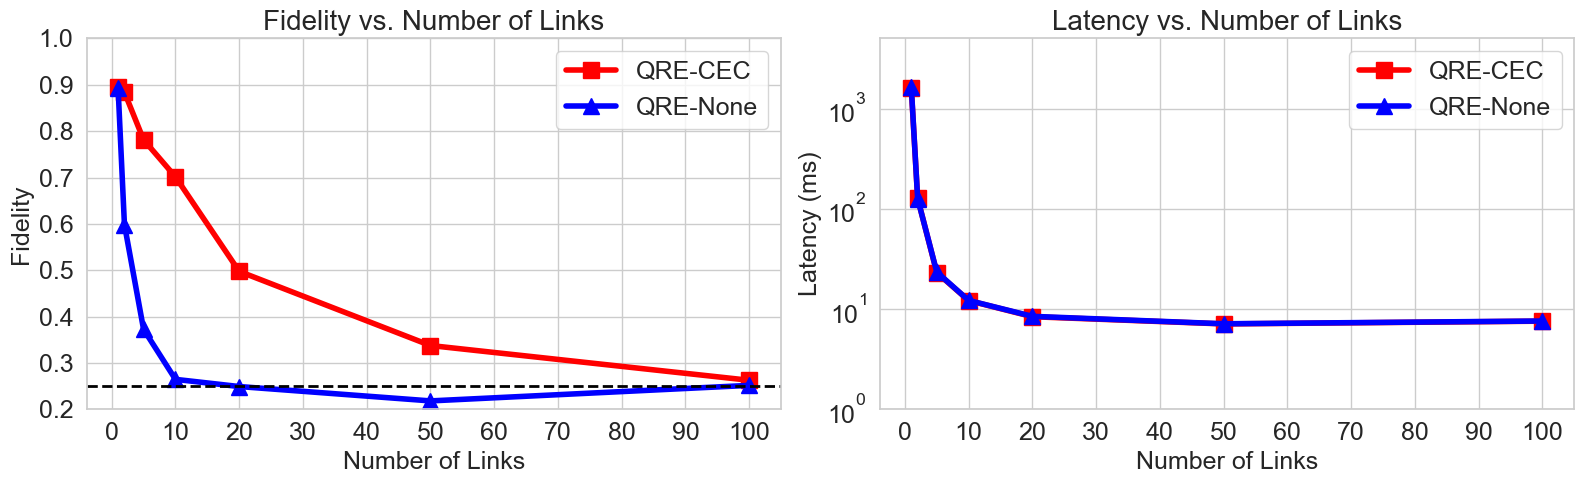

In [379]:
graph4_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph4_link_count_sweep")
graph4_corrected_only_df = load_runner_logs(graph4_corrected_only_log_dir)

if graph4_corrected_only_df.empty:
    print("No Graph 4 runner-ideal data found.")
else:
    graph4_corrected_only_summary = (
        graph4_corrected_only_df.groupby(["num_links", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
            mean_latency_ms=("latency_ms", "mean"),
        )
        .sort_values(["num_links", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax0 = axes[0]
    ax1 = axes[1]

    for protocol in ["cec", "none"]:
        data = graph4_corrected_only_summary[graph4_corrected_only_summary["correction_mode"] == protocol]
        ax0.plot(data["num_links"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
        ax1.plot(data["num_links"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

    ax0.set_xlabel("Number of Links", fontsize=18)
    ax0.set_ylabel("Fidelity", fontsize=18)
    ax0.set_title("Fidelity vs. Number of Links", fontsize=20)
    ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax0.set_ylim(0.2, 1.0)
    ax0.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax0.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    ax0.tick_params(axis="both", labelsize=18)

    ax1.set_xlabel("Number of Links", fontsize=18)
    ax1.set_ylabel("Latency (ms)", fontsize=18)
    ax1.set_title("Latency vs. Number of Links", fontsize=20)
    ax1.set_yscale("log")
    ax1.set_ylim(bottom=0, top=5000)
    ax1.tick_params(axis="both", labelsize=18)
    ax1.set_yticks([1, 10, 100, 1000])
    ax1.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

    ax0.legend(fontsize=18)
    ax1.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(output_dir / "corrected_fidelity_vs_number_of_links_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph4_corrected_only_summary


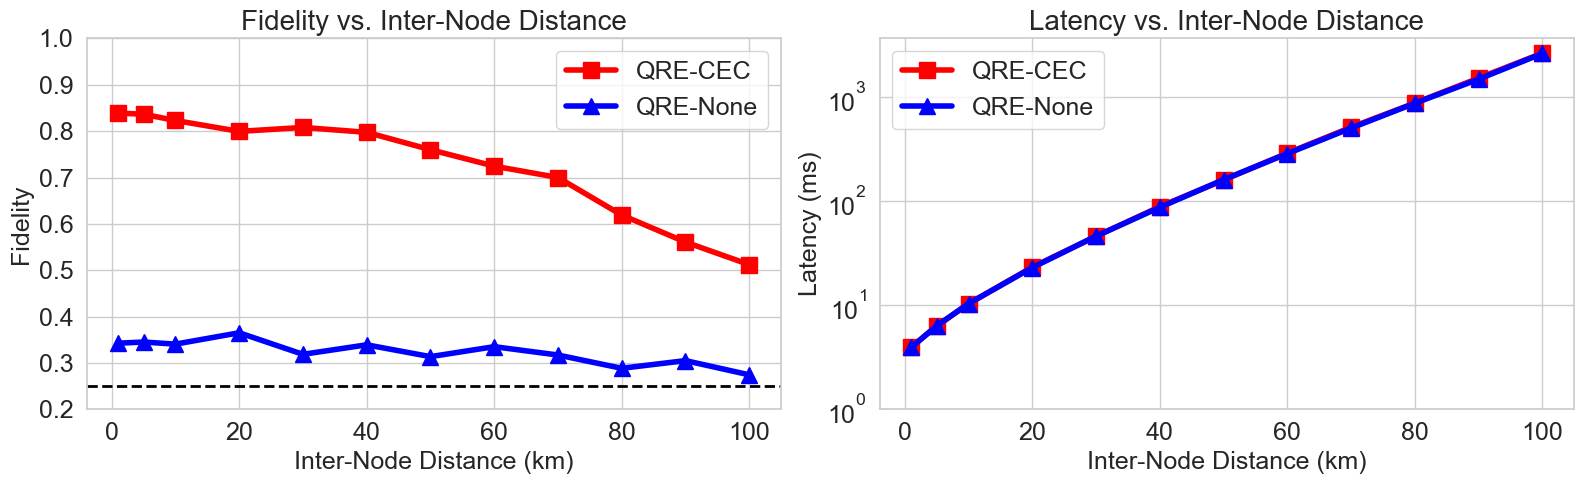

In [380]:
graph5_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph5_inter_node_distance_sweep")
graph5_corrected_only_df = load_runner_logs(graph5_corrected_only_log_dir)

if graph5_corrected_only_df.empty:
    print("No Graph 5 runner-ideal data found.")
else:
    graph5_corrected_only_summary = (
        graph5_corrected_only_df.groupby(["elementary_link_km", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
            mean_latency_ms=("latency_ms", "mean"),
        )
        .sort_values(["elementary_link_km", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
    ax0 = axes[0]
    ax1 = axes[1]

    for protocol in ["cec", "none"]:
        data = graph5_corrected_only_summary[(graph5_corrected_only_summary["correction_mode"] == protocol) & (~graph5_corrected_only_summary["elementary_link_km"].isin([2.5, 7.5, 110, 120]))]
        ax0.plot(data["elementary_link_km"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, linestyle="-", label=names[protocol])
        ax1.plot(data["elementary_link_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

    ax0.set_xlabel("Inter-Node Distance (km)", fontsize=18)
    ax0.set_ylabel("Fidelity", fontsize=18)
    ax0.set_title("Fidelity vs. Inter-Node Distance", fontsize=20)
    ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax0.set_ylim(0.2, 1.0)
    ax0.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax0.tick_params(axis="both", labelsize=18)
    ax0.legend(fontsize=18)

    ax1.set_xlabel("Inter-Node Distance (km)", fontsize=18)
    ax1.set_ylabel("Latency (ms)", fontsize=18)
    ax1.set_title("Latency vs. Inter-Node Distance", fontsize=20)
    ax1.tick_params(axis="both", labelsize=18)
    ax1.legend(fontsize=18)
    ax1.set_yscale("log")
    ax1.set_yticks([1e0, 1e1, 1e2, 1e3])

    plt.tight_layout()
    plt.savefig(output_dir / "corrected_fidelity_vs_inter_node_distance_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph5_corrected_only_summary


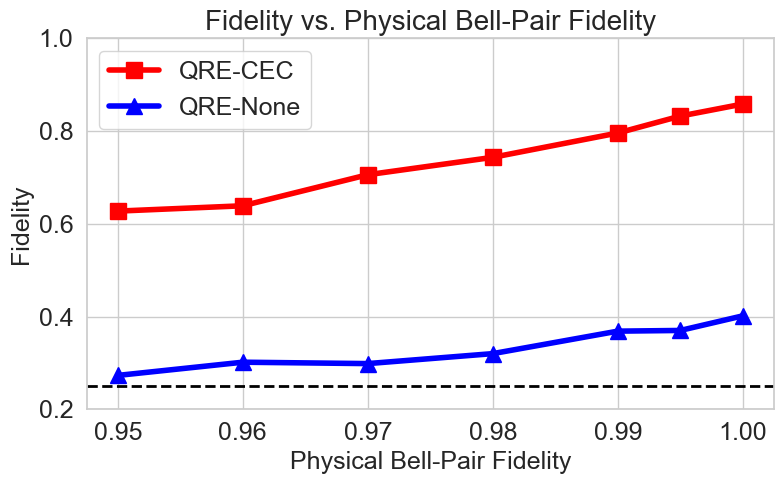

In [381]:
graph6_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph6_physical_bell_pair_fidelity_sweep")
graph6_corrected_only_df = load_runner_logs(graph6_corrected_only_log_dir)

if graph6_corrected_only_df.empty:
    print("No Graph 6 runner-ideal data found.")
else:
    graph6_corrected_only_summary = (
        graph6_corrected_only_df.groupby(["physical_bell_pair_fidelity", "correction_mode"], as_index=False)
        .agg(mean_fidelity_corrected=("fidelity_corrected", "mean"))
        .sort_values(["physical_bell_pair_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for protocol in ["cec", "none"]:
        data = graph6_corrected_only_summary[graph6_corrected_only_summary["correction_mode"] == protocol]
        ax.plot(
            data["physical_bell_pair_fidelity"],
            data["mean_fidelity_corrected"],
            color=colors[protocol],
            marker=markers[protocol],
            linewidth=4,
            markersize=12,
            linestyle="-",
            label=names[protocol],
        )

    ax.set_xlabel("Physical Bell-Pair Fidelity", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Physical Bell-Pair Fidelity", fontsize=20)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=18, loc="upper left")
    plt.tight_layout()
    plt.savefig(output_dir / "corrected_fidelity_vs_physical_bell_pair_fidelity_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph6_corrected_only_summary


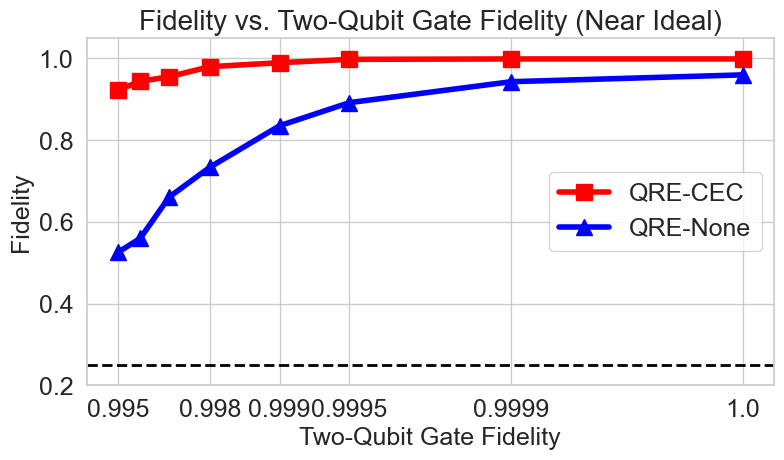

In [382]:
graph7_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph7_twoqubit_gate_fidelity_sweep_nice_params")
graph7_corrected_only_df = load_runner_logs(graph7_corrected_only_log_dir)

if graph7_corrected_only_df.empty:
    print("No Graph 7 runner-ideal data found.")
else:
    graph7_corrected_only_summary = (
        graph7_corrected_only_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False)
        .agg(mean_fidelity_corrected=("fidelity_corrected", "mean"))
        .sort_values(["two_qubit_gate_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )

    graph7_corrected_only_summary["two_qubit_gate_infidelity"] = 1.0 - graph7_corrected_only_summary["two_qubit_gate_fidelity"]
    graph7_corrected_only_summary["two_qubit_gate_infidelity_plot"] = graph7_corrected_only_summary["two_qubit_gate_infidelity"].replace(0.0, 1e-5)

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    for protocol in ["cec", "none"]:
        data = graph7_corrected_only_summary[graph7_corrected_only_summary["correction_mode"] == protocol]
        ax.plot(
            data["two_qubit_gate_infidelity_plot"],
            data["mean_fidelity_corrected"],
            color=colors[protocol],
            marker=markers[protocol],
            linewidth=4,
            markersize=12,
            linestyle="-",
            label=names[protocol],
        )

    ax.set_xscale("log")
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
    ax.set_ylabel("Fidelity", fontsize=18)
    ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity (Near Ideal)", fontsize=20)
    ax.set_ylim(0.2, 1.05)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="y", labelsize=18)
    ax.tick_params(axis="x", labelsize=18)
    ax.legend(fontsize=18)

    tick_fidelities = [0.995, 0.998, 0.999, 0.9995, 0.9999, 1.0]
    tick_positions = [1.0 - value if value < 1.0 else 1e-5 for value in tick_fidelities]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(["0.995", "0.998", "0.999", "0.9995", "0.9999", "1.0"])
    ax.invert_xaxis()

    plt.tight_layout()
    plt.subplots_adjust(top=0.86)
    plt.savefig(output_dir / "corrected_fidelity_vs_two_qubit_gate_fidelity_nice_params_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph7_corrected_only_summary


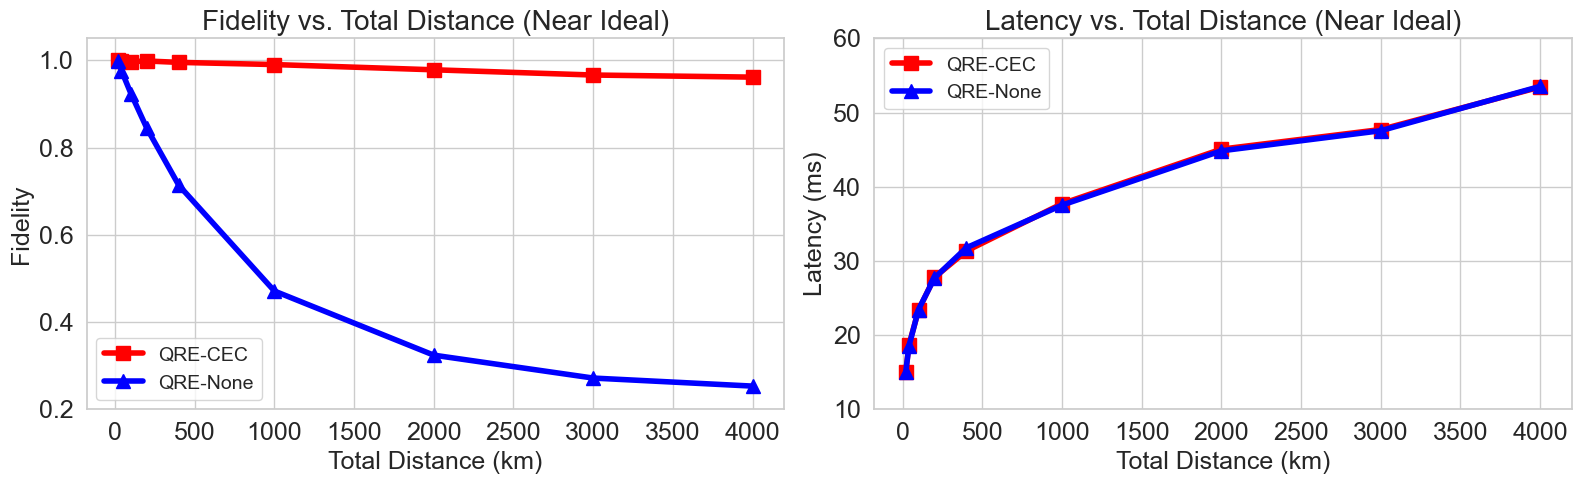

In [400]:
graph8_corrected_only_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal/graph8_ideal_params_distance_sweep")
graph8_corrected_only_df = load_runner_logs(graph8_corrected_only_log_dir)

if graph8_corrected_only_df.empty:
    print("No Graph 8 runner-ideal data found.")
else:
    graph8_corrected_only_summary = (
        graph8_corrected_only_df.groupby(["total_distance_km", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
            mean_latency_ms=("latency_ms", "mean"),
        )
        .sort_values(["total_distance_km", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue"}
    names = {"cec": "QRE-CEC", "none": "QRE-None"}
    markers = {"cec": "s", "none": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax0 = axes[0]
    ax1 = axes[1]

    for protocol in ["cec", "none"]:
        data = graph8_corrected_only_summary[graph8_corrected_only_summary["correction_mode"] == protocol]
        ax0.plot(data["total_distance_km"], data["mean_fidelity_corrected"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=10, linestyle="-", label=names[protocol])
        ax1.plot(data["total_distance_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=10, label=names[protocol])

    ax0.set_xlabel("Total Distance (km)", fontsize=18)
    ax0.set_ylabel("Fidelity", fontsize=18)
    ax0.set_title("Fidelity vs. Total Distance (Near Ideal)", fontsize=20)
    ax0.set_ylim(0.2, 1.05)
    ax0.tick_params(axis="both", labelsize=18)
    ax0.legend(fontsize=14)

    ax1.set_xlabel("Total Distance (km)", fontsize=18)
    ax1.set_ylabel("Latency (ms)", fontsize=18)
    ax1.set_title("Latency vs. Total Distance (Near Ideal)", fontsize=20)
    ax1.tick_params(axis="both", labelsize=18)
    ax1.legend(fontsize=14)
    ax1.set_yticks([10, 20, 30, 40, 50, 60])

    plt.tight_layout()
    plt.savefig(output_dir / "corrected_fidelity_vs_total_distance_nice_params_runner_ideal.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph8_corrected_only_summary


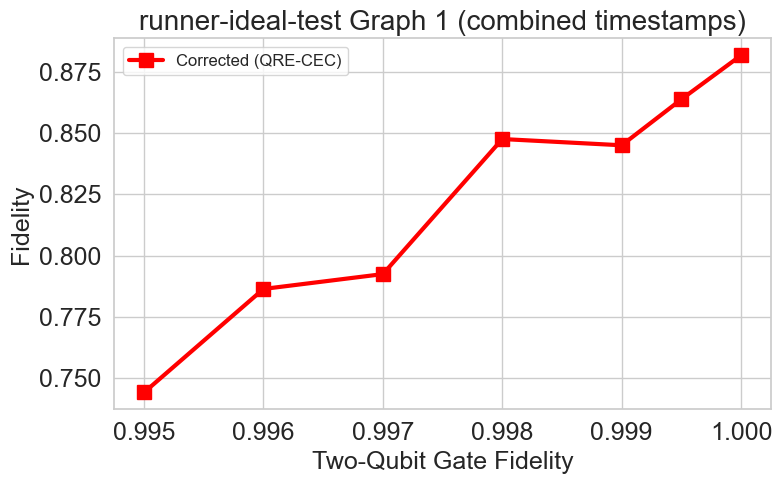

,two_qubit_gate_fidelity,correction_mode,mean_fidelity_raw,mean_fidelity_corrected
0,0.9950,cec,0.561033,0.744131
1,0.9960,cec,0.582160,0.786385
2,0.9970,cec,0.613208,0.792453
3,0.9980,cec,0.676190,0.847619
4,0.9990,cec,0.699531,0.845070
5,0.9995,cec,0.654930,0.863850
6,1.0000,cec,0.729545,0.881818


In [398]:
graph1_runner_ideal_test_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner-ideal-test/graph1_twoqubit_gate_sweep")
graph1_runner_ideal_test_df = load_runner_logs(graph1_runner_ideal_test_log_dir)

if graph1_runner_ideal_test_df.empty:
    print("No Graph 1 runner-ideal-test data found.")
else:
    graph1_runner_ideal_test_df = graph1_runner_ideal_test_df.copy()
    graph1_runner_ideal_test_df["timestamp"] = graph1_runner_ideal_test_df["log_name"].str.extract(r"ts=([^,]+)$")

    target_timestamps = ["20260428_012031"]
    df_plot = graph1_runner_ideal_test_df[
        graph1_runner_ideal_test_df["timestamp"].isin(target_timestamps)
    ]

    if df_plot.empty:
        print(f"No Graph 1 runner-ideal-test data found for timestamps: {target_timestamps}")
    else:
        summary = (
            df_plot.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False)
            .agg(
                mean_fidelity_raw=("fidelity_raw", "mean"),
                mean_fidelity_corrected=("fidelity_corrected", "mean"),
            )
            .sort_values(["two_qubit_gate_fidelity", "correction_mode"])
            .reset_index(drop=True)
        )

        colors = {"cec": "red", "none": "blue"}
        names = {"cec": "QRE-CEC", "none": "QRE-None"}
        markers = {"cec": "s", "none": "^"}

        plt.figure(figsize=(8, 5))
        ax = plt.gca()

        for protocol in ["cec", "none"]:
            data = summary[summary["correction_mode"] == protocol]
            if data.empty:
                continue

            ax.plot(
                data["two_qubit_gate_fidelity"],
                data["mean_fidelity_corrected"],
                color=colors[protocol],
                marker=markers[protocol],
                linewidth=3,
                markersize=10,
                linestyle="-",
                label=f"Corrected ({names[protocol]})",
            )

        ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
        ax.set_ylabel("Fidelity", fontsize=18)
        ax.set_title("runner-ideal-test Graph 1 (combined timestamps)", fontsize=20)
        # ax.set_ylim(0.8, 1.0)
        ax.tick_params(axis="both", labelsize=18)
        ax.legend(fontsize=12, loc="upper left")

        plt.tight_layout()
        plt.savefig(
            output_dir / "corrected_fidelity_runner_ideal_test_graph1_combined.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

        display(summary)

